In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("covid_19_clean_complete.csv")

data.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [10]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


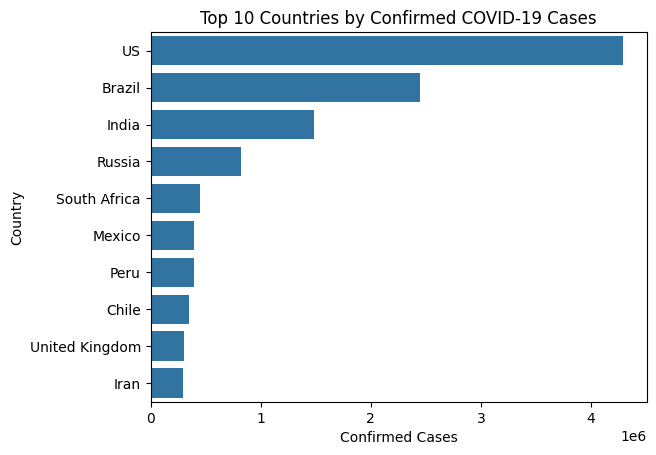

In [11]:
latest = data[data["Date"] == data["Date"].max()]

top_countries = latest.sort_values(by="Confirmed", ascending=False).head(10)

sns.barplot(x="Confirmed", y="Country/Region", data=top_countries)

plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Country")

plt.show()

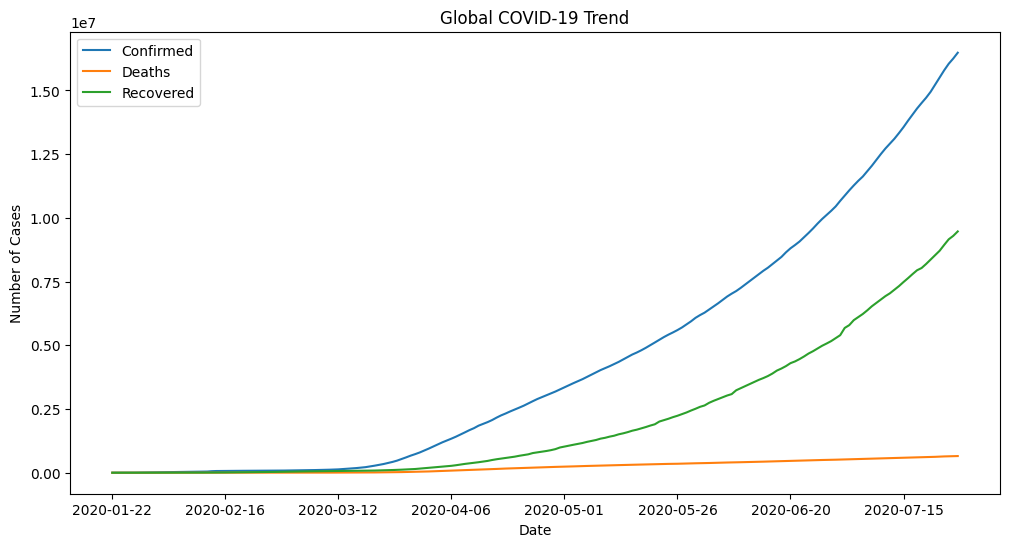

In [12]:
global_data = data.groupby("Date")[["Confirmed","Deaths","Recovered"]].sum()

global_data.plot(figsize=(12,6))

plt.title("Global COVID-19 Trend")
plt.xlabel("Date")
plt.ylabel("Number of Cases")

plt.show()

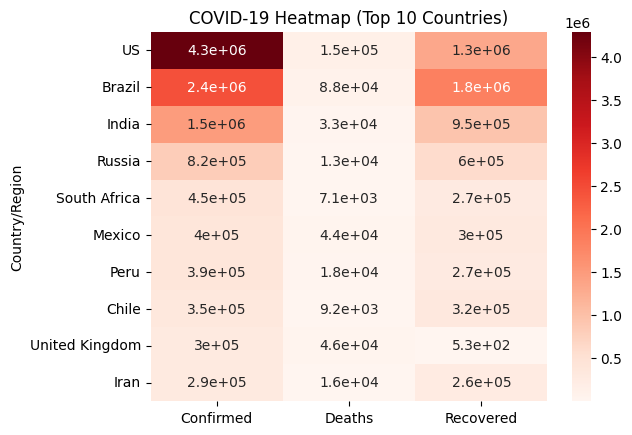

In [13]:
top = data.groupby("Country/Region")[["Confirmed","Deaths","Recovered"]].max().sort_values(by="Confirmed", ascending=False).head(10)

sns.heatmap(top, annot=True, cmap="Reds")

plt.title("COVID-19 Heatmap (Top 10 Countries)")

plt.show()